In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import yfinance as yf

In [2]:
#── Style ────────────────────────────────────────────────────────
BG      = '#0D1117'
SURFACE = '#161B22'
BORDER  = '#30363D'
TEXT    = '#E6EDF3'
MUTED   = '#8B949E'

GREEN   = '#3FB950'
RED     = '#F85149'
BLUE    = '#58A6FF'
YELLOW  = '#D29922'
PURPLE  = '#BC8CFF'

plt.rcParams.update({
    'figure.facecolor':  BG,
    'axes.facecolor':    SURFACE,
    'axes.edgecolor':    BORDER,
    'axes.labelcolor':   TEXT,
    'xtick.color':       MUTED,
    'ytick.color':       MUTED,
    'text.color':        TEXT,
    'grid.color':        BORDER,
    'grid.alpha':        0.5,
    'font.size':         10,
})

In [3]:
df = yf.download("BBCA.JK", period="5y", auto_adjust=True)
df = df[['Open', 'High', 'Low', 'Close', 'Volume']].dropna()
df.columns = df.columns.droplevel(1) if isinstance(df.columns, pd.MultiIndex) else df.columns
print(f"  {df.index[0].date()} → {df.index[-1].date()}  ({len(df)} hari)")

[*********************100%***********************]  1 of 1 completed

  2021-05-17 → 2026-05-15  (1202 hari)


In [4]:
# Moving Averages
df['MA50']  = df['Close'].rolling(50).mean()
df['MA200'] = df['Close'].rolling(200).mean()

# Golden / Death Cross
diff       = df['MA50'] - df['MA200']
df['GC']   = ((diff > 0) & (diff.shift(1) <= 0)).astype(int)  # Golden Cross
df['DC']   = ((diff < 0) & (diff.shift(1) >= 0)).astype(int)  # Death Cross
df['Bull'] = (df['MA50'] > df['MA200'])                        # Regime

# RSI (14)
delta = df['Close'].diff()
gain  = delta.clip(lower=0).rolling(14).mean()
loss  = (-delta.clip(upper=0)).rolling(14).mean()
df['RSI'] = 100 - (100 / (1 + gain / loss))

# MACD
ema12         = df['Close'].ewm(span=12, adjust=False).mean()
ema26         = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD']    = ema12 - ema26
df['Signal']  = df['MACD'].ewm(span=9, adjust=False).mean()
df['Hist']    = df['MACD'] - df['Signal']

# Daily return
df['Return']  = df['Close'].pct_change()

df.dropna(inplace=True)

gc_dates = df[df['GC'] == 1].index
dc_dates = df[df['DC'] == 1].index

# Current state
last       = df.iloc[-1]
is_bull    = bool(last['Bull'])
rsi_now    = round(float(last['RSI']), 1)
macd_bull  = float(last['MACD']) > float(last['Signal'])
price_now  = round(float(last['Close']))

PE_NOW     = 14.1
PE_AVG10Y  = 24.4
PB_NOW     = 7.6
DIV_YIELD  = 3.75

In [5]:
print(f"\n  Harga terakhir : Rp {price_now:,}")
print(f"  MA50           : Rp {round(float(last['MA50'])):,}")
print(f"  MA200          : Rp {round(float(last['MA200'])):,}")
print(f"  Regime         : {'BULL (MA50 > MA200)' if is_bull else 'BEAR (MA50 < MA200)'}")
print(f"  RSI            : {rsi_now}")
print(f"  MACD sinyal    : {'Bullish' if macd_bull else 'Bearish'}")
print(f"  Golden Cross   : {len(gc_dates)}x  |  Death Cross: {len(dc_dates)}x")
print(f"\n  P/E saat ini   : {PE_NOW}x  (hist avg 10Y: {PE_AVG10Y}x)")
print(f"  P/B saat ini   : {PB_NOW}x")
print(f"  Div. Yield     : {DIV_YIELD}%")


  Harga terakhir : Rp 6,100
  MA50           : Rp 6,425
  MA200          : Rp 7,359
  Regime         : BEAR (MA50 < MA200)
  RSI            : 53.3
  MACD sinyal    : Bullish
  Golden Cross   : 2x  |  Death Cross: 3x

  P/E saat ini   : 14.1x  (hist avg 10Y: 24.4x)
  P/B saat ini   : 7.6x
  Div. Yield     : 3.75%



Dashboard tersimpan: BBCA_Dashboard.png


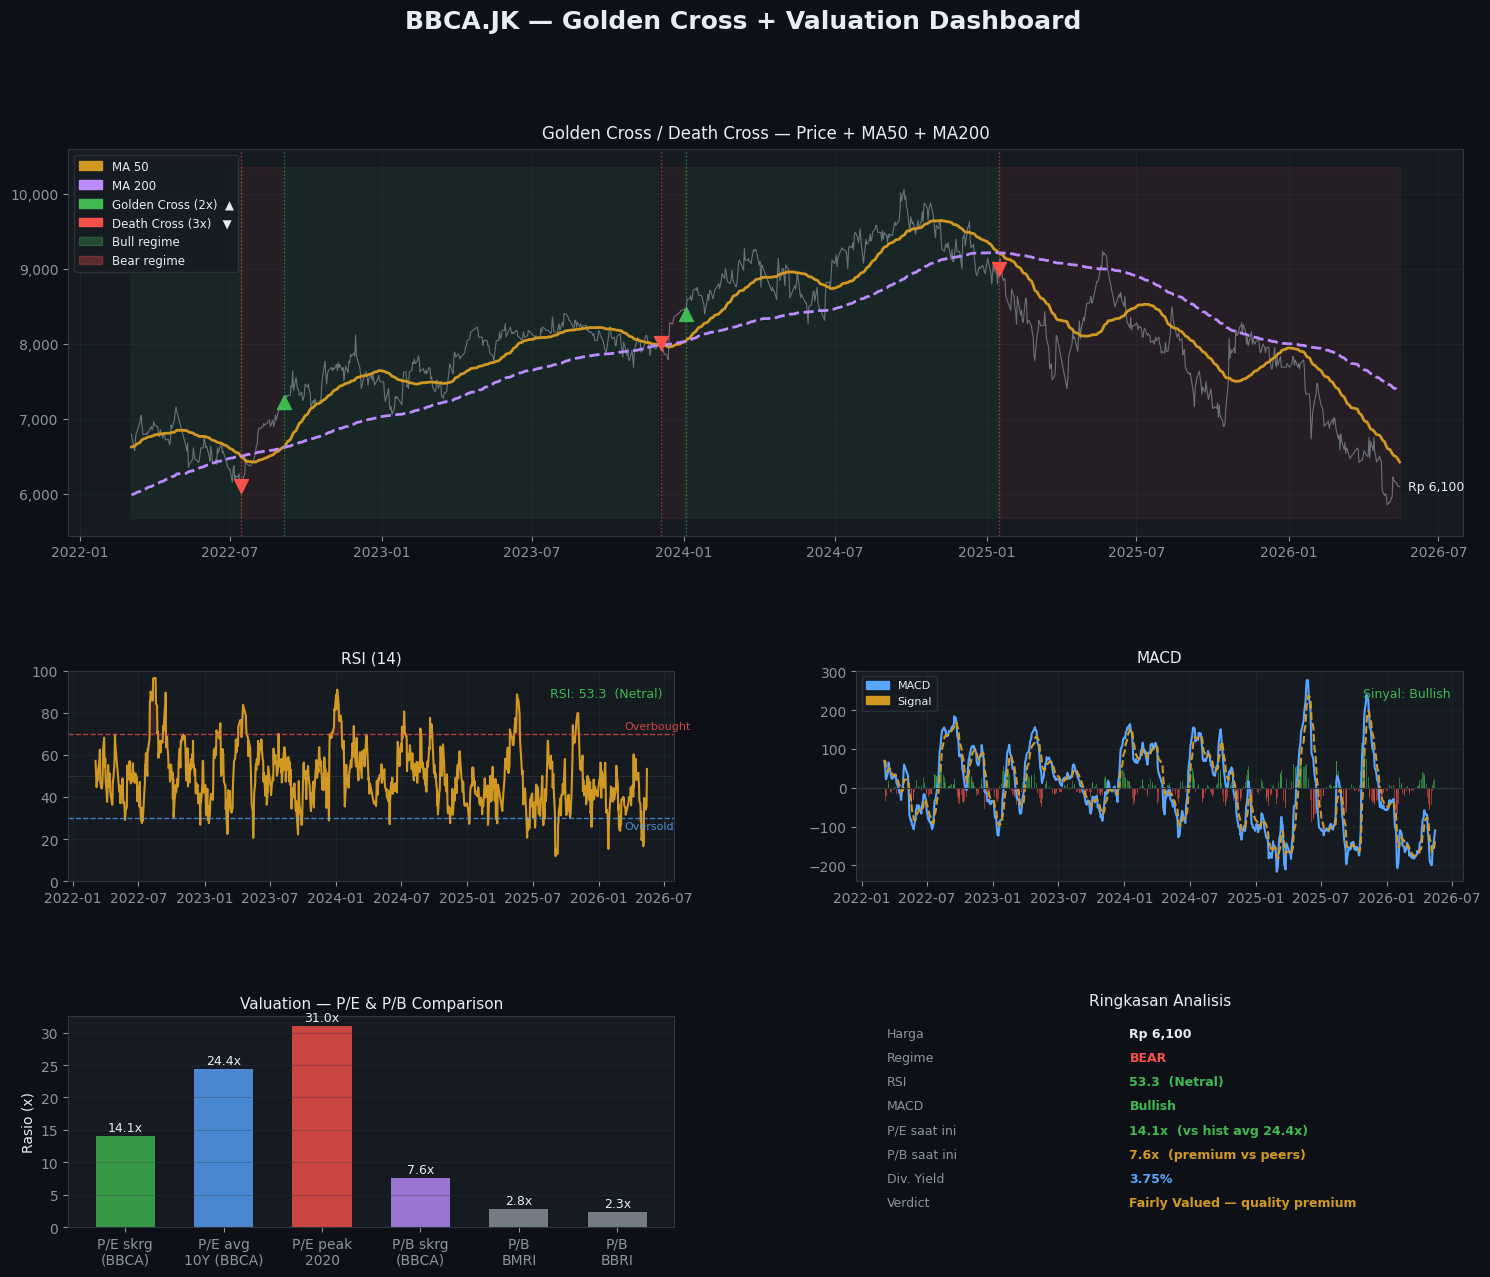

In [7]:
fig = plt.figure(figsize=(18, 14), facecolor=BG)
fig.suptitle('BBCA.JK — Golden Cross + Valuation Dashboard',
             fontsize=18, fontweight='bold', color=TEXT, y=0.98)

gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.5, wspace=0.3,
                       height_ratios=[2.2, 1.2, 1.2])

 # ── Panel 0: Price + MA50 + MA200 + Crosses (full width) ─────────
ax0 = fig.add_subplot(gs[0, :])

ax0.plot(df.index, df['Close'], color=MUTED,  lw=0.8, alpha=0.7, label='Close')
ax0.plot(df.index, df['MA50'],  color=YELLOW, lw=2.0, label='MA 50')
ax0.plot(df.index, df['MA200'], color=PURPLE, lw=2.0, label='MA 200', linestyle='--')

# Regime shading
ax0.fill_between(df.index,
                 df['Close'].min() * 0.97, df['Close'].max() * 1.03,
                 where=df['Bull'],  color=GREEN, alpha=0.07)
ax0.fill_between(df.index,
                 df['Close'].min() * 0.97, df['Close'].max() * 1.03,
                 where=~df['Bull'], color=RED,   alpha=0.07)
 # Golden Cross markers
for d in gc_dates:
    ax0.axvline(d, color=GREEN, lw=1, alpha=0.6, linestyle=':')
    ax0.scatter(d, df.loc[d, 'Close'],
                color=GREEN, s=100, zorder=5, marker='^')

# Death Cross markers
for d in dc_dates:
    ax0.axvline(d, color=RED, lw=1, alpha=0.6, linestyle=':')
    ax0.scatter(d, df.loc[d, 'Close'],
                color=RED, s=100, zorder=5, marker='v')

 # Annotate last price
ax0.annotate(f'  Rp {price_now:,}',
             xy=(df.index[-1], price_now),
             color=TEXT, fontsize=9, va='center')

legend_items = [
    mpatches.Patch(color=YELLOW, label='MA 50'),
    mpatches.Patch(color=PURPLE, label='MA 200'),
    mpatches.Patch(color=GREEN,  label=f'Golden Cross ({len(gc_dates)}x)  ▲'),
    mpatches.Patch(color=RED,    label=f'Death Cross ({len(dc_dates)}x)   ▼'),
    mpatches.Patch(color=GREEN,  alpha=0.3, label='Bull regime'),
    mpatches.Patch(color=RED,    alpha=0.3, label='Bear regime'),
]
ax0.legend(handles=legend_items, loc='upper left', fontsize=8.5,
           facecolor=SURFACE, edgecolor=BORDER, labelcolor=TEXT)
ax0.set_title('Golden Cross / Death Cross — Price + MA50 + MA200',
              color=TEXT, fontsize=12, pad=8)
ax0.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax0.grid(True, alpha=0.3)

# ── Panel 1: RSI ─────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[1, 0])

ax1.plot(df.index, df['RSI'], color=YELLOW, lw=1.5)
ax1.axhline(70, color=RED,   lw=1, ls='--', alpha=0.7)
ax1.axhline(30, color=BLUE,  lw=1, ls='--', alpha=0.7)
ax1.axhline(50, color=MUTED, lw=0.6, ls=':',  alpha=0.5)
ax1.fill_between(df.index, df['RSI'], 70,
                 where=(df['RSI'] >= 70), color=RED,  alpha=0.15)
ax1.fill_between(df.index, df['RSI'], 30,
                 where=(df['RSI'] <= 30), color=BLUE, alpha=0.15)

rsi_color = RED if rsi_now > 70 else (BLUE if rsi_now < 30 else GREEN)
rsi_label = 'Overbought' if rsi_now > 70 else ('Oversold' if rsi_now < 30 else 'Netral')
ax1.text(0.98, 0.92, f'RSI: {rsi_now}  ({rsi_label})',
         ha='right', va='top',
         color=rsi_color, fontsize=9,
         transform=ax1.transAxes)
ax1.text(df.index[-40], 72, 'Overbought', color=RED,  fontsize=8, alpha=0.8)
ax1.text(df.index[-40], 25, 'Oversold',   color=BLUE, fontsize=8, alpha=0.8)
ax1.set_ylim(0, 100)
ax1.set_title('RSI (14)', color=TEXT, fontsize=11)
ax1.grid(True, alpha=0.3)

#── Panel 2: MACD ────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 1])

ax2.plot(df.index, df['MACD'],   color=BLUE,   lw=1.5, label='MACD')
ax2.plot(df.index, df['Signal'], color=YELLOW, lw=1.5, label='Signal', linestyle='--')
colors_hist = [GREEN if v >= 0 else RED for v in df['Hist']]
ax2.bar(df.index, df['Hist'], color=colors_hist, alpha=0.55, width=1.5)
ax2.axhline(0, color=BORDER, lw=0.8)

macd_leg = [
    mpatches.Patch(color=BLUE,   label='MACD'),
    mpatches.Patch(color=YELLOW, label='Signal'),
]
ax2.legend(handles=macd_leg, fontsize=8, facecolor=SURFACE,
           edgecolor=BORDER, labelcolor=TEXT)
signal_txt = 'Bullish' if macd_bull else 'Bearish'
signal_col = GREEN if macd_bull else RED
ax2.text(0.98, 0.92, f'Sinyal: {signal_txt}',
         ha='right', va='top',
         color=signal_col, fontsize=9,
         transform=ax2.transAxes)
ax2.set_title('MACD', color=TEXT, fontsize=11)
ax2.grid(True, alpha=0.3)

# ── Panel 3: Valuation Bar Chart ─────────────────────────────────
ax3 = fig.add_subplot(gs[2, 0])

metrics  = ['P/E skrg\n(BBCA)', 'P/E avg\n10Y (BBCA)', 'P/E peak\n2020', 'P/B skrg\n(BBCA)', 'P/B\nBMRI', 'P/B\nBBRI']
values   = [PE_NOW, PE_AVG10Y, 31.0, PB_NOW, 2.8, 2.3]
bar_cols = [GREEN, BLUE, RED, PURPLE, MUTED, MUTED]

bars = ax3.bar(metrics, values, color=bar_cols, alpha=0.8,
               width=0.6, edgecolor='none')
for bar, val in zip(bars, values):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{val}x', ha='center', va='bottom',
             color=TEXT, fontsize=9)
ax3.set_title('Valuation — P/E & P/B Comparison', color=TEXT, fontsize=11)
ax3.set_ylabel('Rasio (x)')
ax3.grid(True, alpha=0.3, axis='y')

# ── Panel 4: Verdict / Summary ────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 1])
ax4.axis('off')

summary = [
    ('Harga',         f'Rp {price_now:,}',                          TEXT),
    ('Regime',        'BULL — MA50 > MA200' if is_bull else 'BEAR',  GREEN if is_bull else RED),
    ('RSI',           f'{rsi_now}  ({rsi_label})',                   rsi_color),
    ('MACD',          signal_txt,                                     signal_col),
    ('P/E saat ini',  f'{PE_NOW}x  (vs hist avg {PE_AVG10Y}x)',      GREEN),
    ('P/B saat ini',  f'{PB_NOW}x  (premium vs peers)',              YELLOW),
    ('Div. Yield',    f'{DIV_YIELD}%',                                BLUE),
    ('Verdict',       'Fairly Valued — quality premium',             YELLOW),
]

ax4.set_title('Ringkasan Analisis', color=TEXT, fontsize=11, pad=8)
y = 0.95
for label, value, color in summary:
    ax4.text(0.05, y, f'{label}',
         fontsize=9, color=MUTED, va='top',
         transform=ax4.transAxes)
    ax4.text(0.45, y, f'{value}',
         fontsize=9, color=color, va='top',
         fontweight='bold',
         transform=ax4.transAxes)
    y -= 0.115


plt.savefig('BBCA_Dashboard.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
print("\nDashboard tersimpan: BBCA_Dashboard.png")
plt.show()